In [1]:
import pickle
import numpy as np

with open(f"../../attacks/minusface/test.pkl", "rb") as f:
    minusface_data = pickle.load(f)

In [2]:
with open(f"../../attacks/partialface/test.pkl", "rb") as f:
    partialface_data = pickle.load(f)

In [1]:
with open(f"./test.pkl", "rb") as f:
    fracface_data = pickle.load(f)

NameError: name 'pickle' is not defined

In [4]:
fracface_data["filenames"] = sum(fracface_data["filenames"], [])
partialface_data["filenames"] = sum(partialface_data["filenames"], [])
minusface_data["filenames"] = sum(minusface_data["filenames"], [])

In [5]:
import torch
fracface_data["student_embeddings"] = torch.cat(fracface_data["student_embeddings"], dim=0)
partialface_data["student_embeddings"] = torch.cat(partialface_data["student_embeddings"], dim=0)
minusface_data["student_embeddings"] = torch.cat(minusface_data["student_embeddings"], dim=0)

In [39]:
path1 = []
path2 = []
label = []
with open("/path/to/lfw/lfw_ann.txt", "r") as f:
    for line in f.readlines():
        line = line.strip().split(" ")
        label.append(int(line[0]))
        img1 = "/path/to/lfw/" + line[1]
        img2 = "/path/to/lfw/" + line[2]
        path1.append(img1)
        path2.append(img2)

In [7]:
path1[0]

'/path/to/lfw/lfw_112x112/0.bmp'

In [8]:
import numpy as np
from insightface.app import FaceAnalysis
import cv2
app = FaceAnalysis(name='antelopev2', root='./', providers=['CPUExecutionProvider'])

app.prepare(ctx_id=0, det_size=(160, 160))
def get_embedding(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (160,160))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    face = faces[0]
    embedding = face.embedding
    return embedding    

# use a pool of 64 cpus with tqdm
from multiprocessing import Pool
import tqdm

with Pool(130) as p:
    teacher_embeddings = list(tqdm.tqdm(p.imap(get_embedding, path1 + path2), total=len(path1 + path2)))


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (160, 160)


100%|██████████| 12000/12000 [02:39<00:00, 75.20it/s] 


In [24]:
teacher_dict = {}
for i, path in enumerate(path1 + path2):
    teacher_dict[path] = teacher_embeddings[i]

In [36]:
next(iter(teacher_dict.values())).shape

(512,)

In [25]:
fracface_dict = {}
for i, path in enumerate(fracface_data["filenames"]):
    fracface_dict[path] = fracface_data["student_embeddings"][i].cpu().numpy()

In [47]:
pos = []
neg = []
for paths, l in zip(zip(path1, path2), label):
    if paths[0] in teacher_dict.keys() and paths[1] in fracface_dict.keys():
        teacher = teacher_dict[paths[0]]
        fracface = fracface_dict[paths[1]]
        sim = np.dot(teacher, fracface) / (np.linalg.norm(teacher) * np.linalg.norm(fracface))
        if l == 1:
            pos.append(sim)
        else:
            neg.append(sim)

In [46]:
len(pos), len(neg) 

(3000, 0)

In [17]:
path1_pos = [i for i, l in zip(path1, label) if l == 1]
path2_pos = [i for i, l in zip(path2, label) if l == 1]
map_1_to_2 = dict(zip(path1_pos, path2_pos))

In [18]:
minusface_embeddings_1 = []
minusface_embeddings_2 = []
for fname, emb in zip(minusface_data["filenames"], minusface_data["student_embeddings"]):
    if fname in path1:
        minusface_embeddings_1.append((map_1_to_2[fname], emb))
    if fname in path2:
        minusface_embeddings_2.append((fname, emb))

In [19]:
minusface_embeddings_1.sort(key=lambda x: x[0])
minusface_embeddings_2.sort(key=lambda x: x[0])

minusface_embeddings_1 = [emb for _, emb in minusface_embeddings_1]
minusface_embeddings_2 = [emb for _, emb in minusface_embeddings_2]

In [20]:
partialface_embeddings_1 = []
partialface_embeddings_2 = []
for fname, emb in zip(partialface_data["filenames"], partialface_data["student_embeddings"]):
    if fname in path1:
        partialface_embeddings_1.append((map_1_to_2[fname], emb))
    if fname in path2:
        partialface_embeddings_2.append((fname, emb))

fracface_embeddings_1 = []
fracface_embeddings_2 = []  
for fname, emb in zip(fracface_data["filenames"], fracface_data["student_embeddings"]):
    if fname in path1:
        fracface_embeddings_1.append((map_1_to_2[fname], emb))
    if fname in path2:
        fracface_embeddings_2.append((fname, emb))

fracface_embeddings_1.sort(key=lambda x: x[0])
fracface_embeddings_2.sort(key=lambda x: x[0])

fracface_embeddings_1 = [emb for _, emb in fracface_embeddings_1]
fracface_embeddings_2 = [emb for _, emb in fracface_embeddings_2]

partialface_embeddings_1.sort(key=lambda x: x[0])
partialface_embeddings_2.sort(key=lambda x: x[0])
partialface_embeddings_1 = [emb for _, emb in partialface_embeddings_1]
partialface_embeddings_2 = [emb for _, emb in partialface_embeddings_2]

        

In [21]:
teacher_embeddings_1 = []
teacher_embeddings_2 = []
for fname, emb in zip(path1+path2, teacher_embeddings):
    if fname in path1:
        teacher_embeddings_1.append((map_1_to_2[fname], emb))
    if fname in path2:
        teacher_embeddings_2.append((fname, emb))

teacher_embeddings_1.sort(key=lambda x: x[0])
teacher_embeddings_2.sort(key=lambda x: x[0])
teacher_embeddings_1 = [emb for _, emb in teacher_embeddings_1]
teacher_embeddings_2 = [emb for _, emb in teacher_embeddings_2]

KeyError: '/path/to/lfw/lfw_112x112/600.bmp'

In [ ]:
teacher_embeddings_1 = np.array(teacher_embeddings_1)
teacher_embeddings_2 = np.array(teacher_embeddings_2)
fracface_embeddings_1 = np.array(fracface_embeddings_1)
fracface_embeddings_2 = np.array(fracface_embeddings_2)
partialface_embeddings_1 = np.array(partialface_embeddings_1)
partialface_embeddings_2 = np.array(partialface_embeddings_2)
minusface_embeddings_1 = np.array(minusface_embeddings_1)
minusface_embeddings_2 = np.array(minusface_embeddings_2)

In [ ]:
minusface_embeddings_1 = minusface_embeddings_1 / np.linalg.norm(minusface_embeddings_1, axis=-1, keepdims=True)
partialface_embeddings_2 = partialface_embeddings_2 / np.linalg.norm(partialface_embeddings_2, axis=-1, keepdims=True)
minusface_embeddings_2 = minusface_embeddings_2 / np.linalg.norm(minusface_embeddings_2, axis=-1, keepdims=True)
partialface_embeddings_1 = partialface_embeddings_1 / np.linalg.norm(partialface_embeddings_1, axis=-1, keepdims=True)
teacher_embeddings_1 = teacher_embeddings_1 / np.linalg.norm(teacher_embeddings_1, axis=-1, keepdims=True)
teacher_embeddings_2 = teacher_embeddings_2 / np.linalg.norm(teacher_embeddings_2, axis=-1, keepdims=True)
fracface_embeddings_1 = fracface_embeddings_1 / np.linalg.norm(fracface_embeddings_1, axis=-1, keepdims=True)
fracface_embeddings_2 = fracface_embeddings_2 / np.linalg.norm(fracface_embeddings_2, axis=-1, keepdims=True)

In [ ]:
teacher_embeddings_2.shape, fracface_embeddings_2.shape, partialface_embeddings_2.shape, minusface_embeddings_2.shape

((3000, 512), (3000, 512), (3000, 512), (3000, 512))

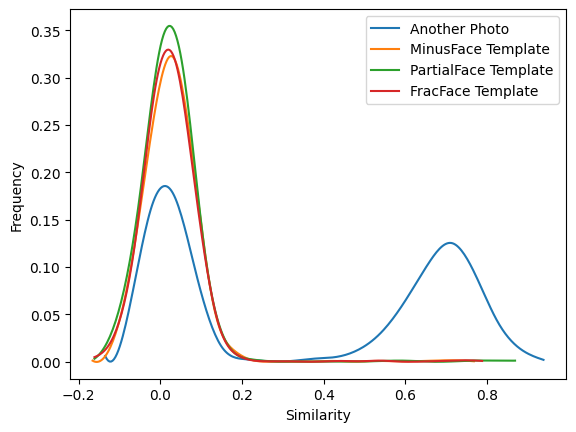

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

sims_teachers = np.diagonal(((teacher_embeddings_1 @ teacher_embeddings_2.T)))
# sims_teachers = sims_teachers[sims_teachers>0.2]
sim_teacher_minusface = np.diagonal(((teacher_embeddings_1 @ minusface_embeddings_1.T)))
sim_teacher_partial = np.diagonal(((teacher_embeddings_1 @ partialface_embeddings_1.T)))
sim_teacher_fracface = np.diagonal(((teacher_embeddings_1 @ fracface_embeddings_1.T)))
import matplotlib.pyplot as plt
 
import numpy as np
import matplotlib.pyplot as plt

def plot(data, label):
    counts, bin_edges = np.histogram(data, bins=20)
    prob = counts / counts.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    xnew = np.linspace(bin_centers.min(), bin_centers.max(), 300)  
    spl = make_interp_spline(bin_centers, prob)
    prob_smooth = spl(xnew)
    plt.plot(xnew, prob_smooth, label=label)

plot(sims_teachers, "Another Photo")
plot(sim_teacher_minusface, "MinusFace Template")
plot(sim_teacher_partial, "PartialFace Template") 
plot(sim_teacher_fracface, "FracFace Template")

plt.xlabel("Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show() 


In [ ]:
block_idx = [] 
for x,y in zip(*np.where((teacher_embeddings_1 @ teacher_embeddings_2.T) > 0.3)):
    if x == y:
        continue
    block_idx.append(x)
    block_idx.append(y)

In [ ]:
set(range(minusface_embeddings_1.shape[0])) - set(block_idx)

2222

In [ ]:

sources = ["minusface_embeddings_1", "teacher_embeddings_1", "partialface_embeddings_1", "fracface_embeddings_1"]
targets = ["minusface_embeddings_2", "teacher_embeddings_2", "partialface_embeddings_2", "fracface_embeddings_2"]

mapping = { 
    "minusface_embeddings_1": minusface_embeddings_1,
    "teacher_embeddings_1": teacher_embeddings_1,
    "partialface_embeddings_1": partialface_embeddings_1,
    "minusface_embeddings_2": minusface_embeddings_2,
    "teacher_embeddings_2": teacher_embeddings_2,
    "partialface_embeddings_2": partialface_embeddings_2,
    "fracface_embeddings_1": fracface_embeddings_1,
    "fracface_embeddings_2": fracface_embeddings_2,}

data = []

for source in sources:
    for target in targets:
        source_embeddings_1 = mapping[source]
        target_embeddings_2 = mapping[target]
        ranks = []
        for i in range(len(minusface_embeddings_1)):
            query = source_embeddings_1[i] 
            keys = target_embeddings_2
            sims = np.dot(keys, query)  
            ranks.append(len(sims) - (np.where(np.argsort(sims) == i)[0][0])) 
        data.append({
            "source": f"{source}".split('=')[0],
            "target": f"{target}".split('=')[0],
            "mean_rank": np.mean(ranks)/len(sims),
            "top1_recall": np.mean(np.array(ranks)==1),
            "top_5_recall": np.mean(np.array(ranks)<=5),
        })

In [ ]:
import pandas as pd 
pd.DataFrame(data)

,source,target,mean_rank,top1_recall,top_5_recall
0,minusface_embeddings_1,minusface_embeddings_2,0.007651,0.461000,0.687000
1,minusface_embeddings_1,teacher_embeddings_2,0.005374,0.466000,0.708333
2,minusface_embeddings_1,partialface_embeddings_2,0.006366,0.468667,0.707667
3,minusface_embeddings_1,fracface_embeddings_2,0.010524,0.451000,0.668000
4,teacher_embeddings_1,minusface_embeddings_2,0.005491,0.476667,0.711333
5,teacher_embeddings_1,teacher_embeddings_2,0.002242,0.477000,0.714000
6,teacher_embeddings_1,partialface_embeddings_2,0.004234,0.469667,0.704333
7,teacher_embeddings_1,fracface_embeddings_2,0.007064,0.472667,0.692000
8,partialface_embeddings_1,minusface_embeddings_2,0.007922,0.467000,0.695333
9,partialface_embeddings_1,teacher_embeddings_2,0.005702,0.471667,0.707667


In [ ]:
# import pandas as pd

# print(pd.DataFrame(data).to_latex(float_format="%.4f", index=False, caption="Linkage Results between MinusFace, PartialFace, and Teacher Embeddings", label="tab:linkage_results").replace("_", " ").replace("embeddings 1", "").replace("embeddings 2", "").replace("teacher", "original image"))

In [ ]:
# import cv2
# from insightface.app import FaceAnalysis
# import torch

# app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
# app.prepare(ctx_id=0, det_size=(160, 160))



# def compare_face_insight(img1, img2):
#     try:
#         image = np.array(img1.convert("RGB"))[:,:,::-1]
#         faces = app.get(image)
#         faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         image = np.array(img2.convert("RGB"))[:,:,::-1]
#         faces = app.get(image)
#         faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
#         return cos_sim
#     except Exception as e:
#         print("Error in compare_face_insight:", e)
#         return None

In [ ]:
# import os
# ids = os.listdir("/path/to/casia-webface/")

In [ ]:
# from PIL import Image
# sims = []
# for id in ids:
#     faces = os.listdir(f"/path/to/casia-webface/{id}/")
#     selected_faces = faces[:2]
#     res = compare_face_insight(Image.open(f"/path/to/casia-webface/{id}/{selected_faces[0]}"), Image.open(f"/path/to/casia-webface/{id}/{selected_faces[1]}"))
#     if res is not None:
#         if res > 0.3:
#             sims.append(res)
#     print(sum(sims)/len(sims), end="\r", flush=True)